# Support Vector Machines with Python and Scikit-Learn

In this project, I develop a Support Vector Machines (SVM) classifier to detect **Brugada Syndrome** using ECG signals.

The dataset used is the **Brugada-HUCA ECG dataset**, which contains 12-lead electrocardiogram recordings collected for cardiac analysis. This dataset reflects real-world challenges such as class imbalance and limited sample size.

The objective of this project is to investigate how machine learning can support early detection of Brugada Syndrome, contributing to improved clinical decision-making and prevention of sudden cardiac death.

## Table of Contents

1. Introduction to Support Vector Machines  
2. Support Vector Machines Intuition  
3. Kernel Trick  
4. Problem Statement: Detection of Brugada Syndrome  
5. Dataset Description (Brugada-HUCA ECG Dataset)  
6. Import Libraries  
7. Load Dataset  
8. Exploratory Data Analysis  
9. Feature and Target Variable Definition  
10. Split data into separate training and test set  
11. Feature Scaling  
12. Run SVM with default hyperparameters
13. Run SVM with linear kernel
14. Run SVM with polynomial kernel
15. Run SVM with sigmoid kernel
16. Confusion matrix
17. Classification metrices
18. ROC - AUC
19. Stratified k-fold Cross Validation with shuffle split
20. Hyperparameter optimization using GridSearch CV
21. Results and conclusion

## 1. Introduction to Support Vector Machines

**Support Vector Machines** (SVMs) are machine learning algorithms that are widely used for classification and regression tasks. SVMs are considered powerful models for classification, regression, and outlier detection. An SVM classifier builds a model that assigns new data points into predefined categories, making it a non-probabilistic binary linear classifier.

The original SVM algorithm was developed by Vladimir N. Vapnik and Alexey Ya. Chervonenkis in 1963. At that time, the method was limited to linear classification using hyperplanes. Later, in 1992, Bernhard E. Boser, Isabelle M. Guyon, and Vladimir N. Vapnik introduced the concept of non-linear classification using the **kernel trick** applied to maximum-margin hyperplanes. The modern formulation of SVM was proposed by Corinna Cortes and Vladimir N. Vapnik in 1993 and officially published in 1995.

SVMs can be used for linear classification tasks. In addition, they can efficiently perform non-linear classification using the **kernel trick**, which implicitly maps input data into higher-dimensional feature spaces.

In this project, SVM is used to classify ECG data for the detection of **Brugada Syndrome**, a cardiac condition that can lead to sudden cardiac death. Due to the complex and non-linear nature of ECG signals, SVM becomes a suitable model for capturing patterns that distinguish between normal and abnormal heart conditions.



## 2. Support Vector Machines Intuition

Now, we should be familiar with some SVM terminology. These concepts are important to understand how SVM works in classifying ECG data for detecting Brugada Syndrome.


### Hyperplane

A hyperplane is a decision boundary which separates between given set of data points having different class labels.

In this project, the hyperplane separates ECG samples into **Brugada** and **Normal** classes. The SVM classifier selects a hyperplane with the maximum margin, known as the `maximum margin hyperplane`. The corresponding classifier is called the `maximum margin classifier`.


### Support Vectors

Support vectors are the sample data points which are closest to the hyperplane. These points are critical because they define the position and orientation of the decision boundary.

In the context of ECG data, support vectors represent the most informative samples that help distinguish subtle differences between Brugada and Normal patterns.


### Margin

A margin is the separation gap between the two classes. It is calculated as the perpendicular distance from the hyperplane to the nearest data points (support vectors).

SVM aims to maximize this margin to improve generalization and reduce classification errors.


### SVM Under the hood

In SVMs, the main objective is to select a hyperplane with the maximum possible margin between support vectors. This is done through the following steps:

1. Generate multiple hyperplanes that can separate the classes. Among these, we look for the one that provides the largest margin between classes.

2. Select the hyperplane that maximizes the distance to the nearest data points from each class. This is known as the **maximum margin hyperplane**, and the resulting classifier is called the **maximum margin classifier**.


### Problem with dispersed datasets

Sometimes, the data points are not linearly separable, especially in complex datasets like ECG signals.

In such cases, SVM uses the `kernel trick` to transform the data into a higher-dimensional space where linear separation becomes possible. This allows the model to capture more complex patterns in ECG signals, which is important for detecting conditions like Brugada Syndrome.

## 3. Kernel Trick

In practice, the SVM algorithm is implemented using a `kernel`. It uses a technique called the `kernel trick`. In simple terms, a `kernel` is a function that maps data into a higher-dimensional space where it becomes easier to separate.

A kernel transforms low-dimensional input data into a higher-dimensional space, allowing non-linearly separable data to become linearly separable. This is especially useful when dealing with complex patterns, such as ECG signals, where the relationship between features is not purely linear.

Thus, the kernel trick helps in building a more accurate classifier by enabling SVM to capture complex decision boundaries.

In the context of SVMs, there are four commonly used kernels:
- `Linear kernel`
- `Polynomial kernel`
- `Radial Basis Function (RBF) kernel` (also known as Gaussian kernel)
- `Sigmoid kernel`

In this project, various kernels such as **linear**, **polynomial**, **RBF**, and **sigmoid** are explored for classification.

## 4. The Problem Statement

In this project, I aim to classify ECG signals into categories: `Brugada Syndrome`, `Normal`, and `Ambiguous`. Brugada Syndrome represents a minority positive class, while normal ECG signals form the majority negative class. This class imbalance makes the classification task more challenging and requires special handling.

To address this problem, I implement the Support Vector Machines (SVM) classification algorithm using Python and Scikit-Learn. The goal is to build a model that can accurately distinguish between Brugada, Normal, and Ambiguous ECG patterns.

To improve model performance, I also apply data preprocessing techniques such as feature scaling and class balancing using SMOTE. These steps are important to ensure that the model can learn effectively from imbalanced biomedical data.

The dataset used in this project consists of ECG-derived features related to Brugada Syndrome, which are used to train and evaluate the classification model.

## 5. Dataset Description

In this project, I use the **Brugada-HUCA dataset**, which is publicly available on PhysioNet:
[Brugada-HUCA Dataset (PhysioNet)](https://physionet.org/content/brugada-huca/1.0.0/)

This dataset contains 12-lead electrocardiogram (ECG) recordings specifically designed for the study and classification of **Brugada Syndrome**, a rare but potentially life-threatening cardiac condition.

The dataset consists of a total of 363 subjects, including:
- 69 patients diagnosed with Brugada Syndrome (Class 1)
- 287 healthy control subjects (Class 0)
- 7 ambiguous cases (Class 2)

Each ECG recording has a duration of approximately 12 seconds and is sampled at a frequency of 100 Hz. The signals include all standard 12 ECG leads (I, II, III, aVR, aVL, aVF, V1–V6) [Brugada-HUCA Dataset (PhysioNet)](https://physionet.org/content/brugada-huca/1.0.0/)

The dataset represents a multi-class classification problem, where:
- Class `0` indicates normal ECG
- Class `1` indicates Brugada Syndrome
- Class `2` indicates ambiguous cases

Similar to real-world medical datasets, this dataset is **imbalanced**, with significantly fewer Brugada cases compared to normal samples. This imbalance makes the classification task more challenging and motivates the use of techniques such as SMOTE for balancing the data.

### Attribute Information:

The dataset consists of two main components:

1. **ECG waveform data**  
   Raw ECG signals stored in WFDB format (.dat and .hea files), representing electrical activity of the heart.

2. **Metadata (CSV file)**  
   Contains important variables such as:
   - `patient_id` → unique identifier  
   - `brugada` → target label (0 = Normal, 1 = Brugada)  
   - clinical indicators (if available)

In this project, the raw ECG signals are processed into numerical features, which are then used as input for the SVM classification model.

## 6. Import libraries


I will start off by importing the required Python libraries.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [66]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [67]:
import warnings

warnings.filterwarnings('ignore')

## 7.Load dataset

In [68]:
!wget -r -N -c -np https://physionet.org/files/brugada-huca/1.0.0/

Streaming output truncated to the last 5000 lines.
Last-modified header missing -- time-stamps turned off.
2026-03-28 10:52:00 (120 MB/s) - ‘physionet.org/files/brugada-huca/1.0.0/files/3133602/index.html’ saved [491]

--2026-03-28 10:52:00--  https://physionet.org/files/brugada-huca/1.0.0/files/3136075/
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/brugada-huca/1.0.0/files/3136075/index.html’

physionet.org/files     [ <=>                ]     491  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-03-28 10:52:00 (146 MB/s) - ‘physionet.org/files/brugada-huca/1.0.0/files/3136075/index.html’ saved [491]

--2026-03-28 10:52:00--  https://physionet.org/files/brugada-huca/1.0.0/files/3138453/
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.

In [69]:
data = '/content/physionet.org/files/brugada-huca/1.0.0/metadata.csv'

df = pd.read_csv(data)

## 8. Exploratory data analysis

Now, I will explore the data to gain insights about the data.

In [70]:
df.shape

(363, 4)

We can see that there are 363 instances and 4 variables in the data set.

### Class Distribution

Now, let’s examine the distribution of the target variable `brugada`.

Dataset dimensions: (363, 4)

Number of data per category:
brugada
0    287
1     69
2      7
Name: count, dtype: int64


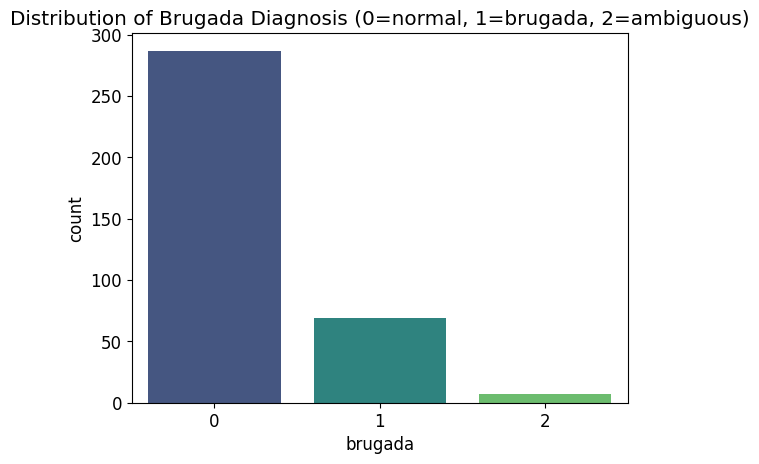

In [71]:
print(f"Dataset dimensions: {df.shape}")
print("\nNumber of data per category:")
print(df['brugada'].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='brugada', data=df, palette='viridis')
plt.title('Distribution of Brugada Diagnosis (0=normal, 1=brugada, 2=ambiguous)')
plt.show()

### Visualization of Class Distribution

The bar chart above shows the distribution of each class in the `brugada` variable.

It can be seen that:
- Class `0` (Normal) dominates the dataset  
- Class `1` (Brugada) is significantly smaller  
- Class `2` (Ambiguous) has very few samples  

This confirms that the dataset is **imbalanced**, and also highlights the presence of ambiguous cases that need to be handled during preprocessing.

In [72]:
df.head()

,patient_id,basal_pattern,sudden_death,brugada
0,188981,1,0,1
1,251972,0,0,0
2,265715,0,0,0
3,267628,0,0,0
4,267630,0,0,1


We can observe that the dataset consists of several feature variables and one target variable.

The target variable is `brugada`, which represents the class label:
- `0` → Normal ECG  
- `1` → Brugada Syndrome  
- `2` → Ambiguous  

The feature variables are numerical values derived from ECG signals and will be used as input for the classification model.

Now, I will display the column names to check for any inconsistencies such as leading or trailing spaces.

In [73]:
col_names = df.columns

col_names

Index(['patient_id', 'basal_pattern', 'sudden_death', 'brugada'], dtype='object')


Here, we store the column names of the dataset in a variable `col_names` for easier access and inspection.

This allows us to review all feature names and ensure they are correctly labeled.

In [74]:
df['brugada'].value_counts()

,count
brugada,
0,287
1,69
2,7


### Class Distribution

From the output above, we can observe the distribution of the target variable `brugada`:

- Class `0` → Normal ECG  
- Class `1` → Brugada Syndrome  
- Class `2` → Ambiguous cases  

The presence of class `2` indicates samples that are not clearly classified as either normal or Brugada.

Additionally, the dataset is **imbalanced**, with the number of normal samples significantly higher than Brugada cases.

In [75]:
df['brugada'].value_counts()/float(len(df))

,count
brugada,
0,0.790634
1,0.190083
2,0.019284


### Proportion of target classes

Here, we calculate the proportion of each class in the target variable `brugada`.

This helps us understand the class distribution and identify whether the dataset is imbalanced.

We can see that the dataset is imbalanced, with class 0 being the majority class and class 1 and 2 forming minority classes. The ambiguous class (2) has very few samples, which may affect model performance.

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363 entries, 0 to 362
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   patient_id     363 non-null    int64
 1   basal_pattern  363 non-null    int64
 2   sudden_death   363 non-null    int64
 3   brugada        363 non-null    int64
dtypes: int64(4)
memory usage: 11.5 KB


We can see that there are no missing values in the dataset and all the variables are numerical variables.

In [77]:
df.isnull().sum()

,0
patient_id,0
basal_pattern,0
sudden_death,0
brugada,0


We can see that there are no missing values in the dataset.

### Summary of numerical variables

There are 4 variables in the dataset.

All variables are numerical. The variables `basal_pattern` and `sudden_death` represent clinical features, while `brugada` is the target variable.

The target variable `brugada` is a discrete variable with three classes (0 = normal, 1 = Brugada, 2 = ambiguous).

There are no missing values in the dataset.

### Outliers in numerical variables

In [78]:
round(df.describe(),2)

,patient_id,basal_pattern,sudden_death,brugada
count,363.00,363.00,363.00,363.00
mean,1325623.60,0.13,0.03,0.23
std,812023.63,0.33,0.17,0.46
min,188981.00,0.00,0.00,0.00
25%,893239.50,0.00,0.00,0.00
50%,1160261.00,0.00,0.00,0.00
75%,1359450.50,0.00,0.00,0.00
max,3139196.00,1.00,1.00,2.00


On closer inspection, we can suspect that some numerical variables may contain outliers.

To further investigate this, boxplots will be used to visualize the presence of outliers in these variables.

Text(0, 0.5, 'brugada')

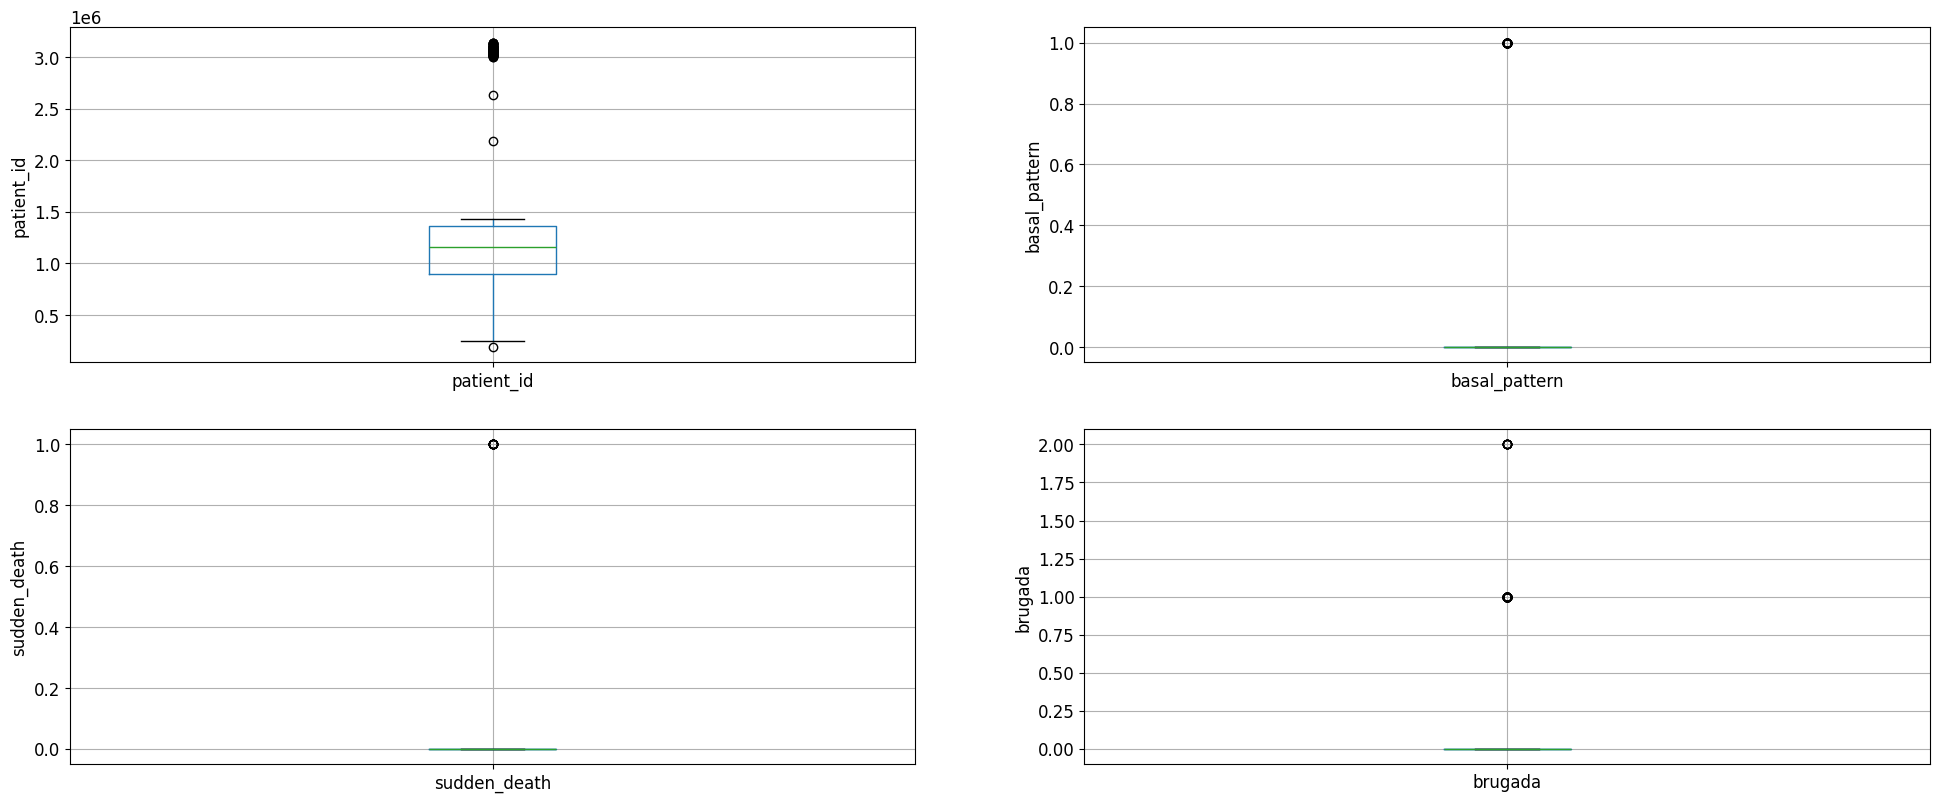

In [79]:
plt.figure(figsize=(24,20))


plt.subplot(4, 2, 1)
fig = df.boxplot(column='patient_id')
fig.set_title('')
fig.set_ylabel('patient_id')


plt.subplot(4, 2, 2)
fig = df.boxplot(column='basal_pattern')
fig.set_title('')
fig.set_ylabel('basal_pattern')


plt.subplot(4, 2, 3)
fig = df.boxplot(column='sudden_death')
fig.set_title('')
fig.set_ylabel('sudden_death')


plt.subplot(4, 2, 4)
fig = df.boxplot(column='brugada')
fig.set_title('')
fig.set_ylabel('brugada')


The boxplots do not provide meaningful insight for these variables since they are mostly binary or categorical. Therefore, outlier detection is not applicable in this case.

### Handling Outliers with SVM

There are two variants of SVM: the hard-margin SVM and the soft-margin SVM.

The hard-margin variant does not allow any misclassification and attempts to find a hyperplane that perfectly separates the data with maximum margin. This approach is not suitable for real-world datasets, especially when outliers are present.

The soft-margin SVM, on the other hand, allows some misclassifications. It introduces a regularization parameter `C` that controls the trade-off between maximizing the margin and minimizing classification errors.

A smaller value of `C` allows more flexibility and tolerates outliers, resulting in a wider margin. A larger value of `C` tries to classify all training examples correctly, which may lead to overfitting when outliers are present.

In this project, the soft-margin SVM is used to handle potential noise and variability in ECG data, which is common in real-world medical datasets.

### Check the Distribution of Variables

To better understand the data, histograms are plotted for each numerical variable. This helps to visualize the distribution of values and identify whether the variables are normally distributed or skewed.

Understanding the distribution is important for detecting potential outliers and determining whether preprocessing steps such as scaling are needed.

Text(0, 0.5, 'Number of metadata')

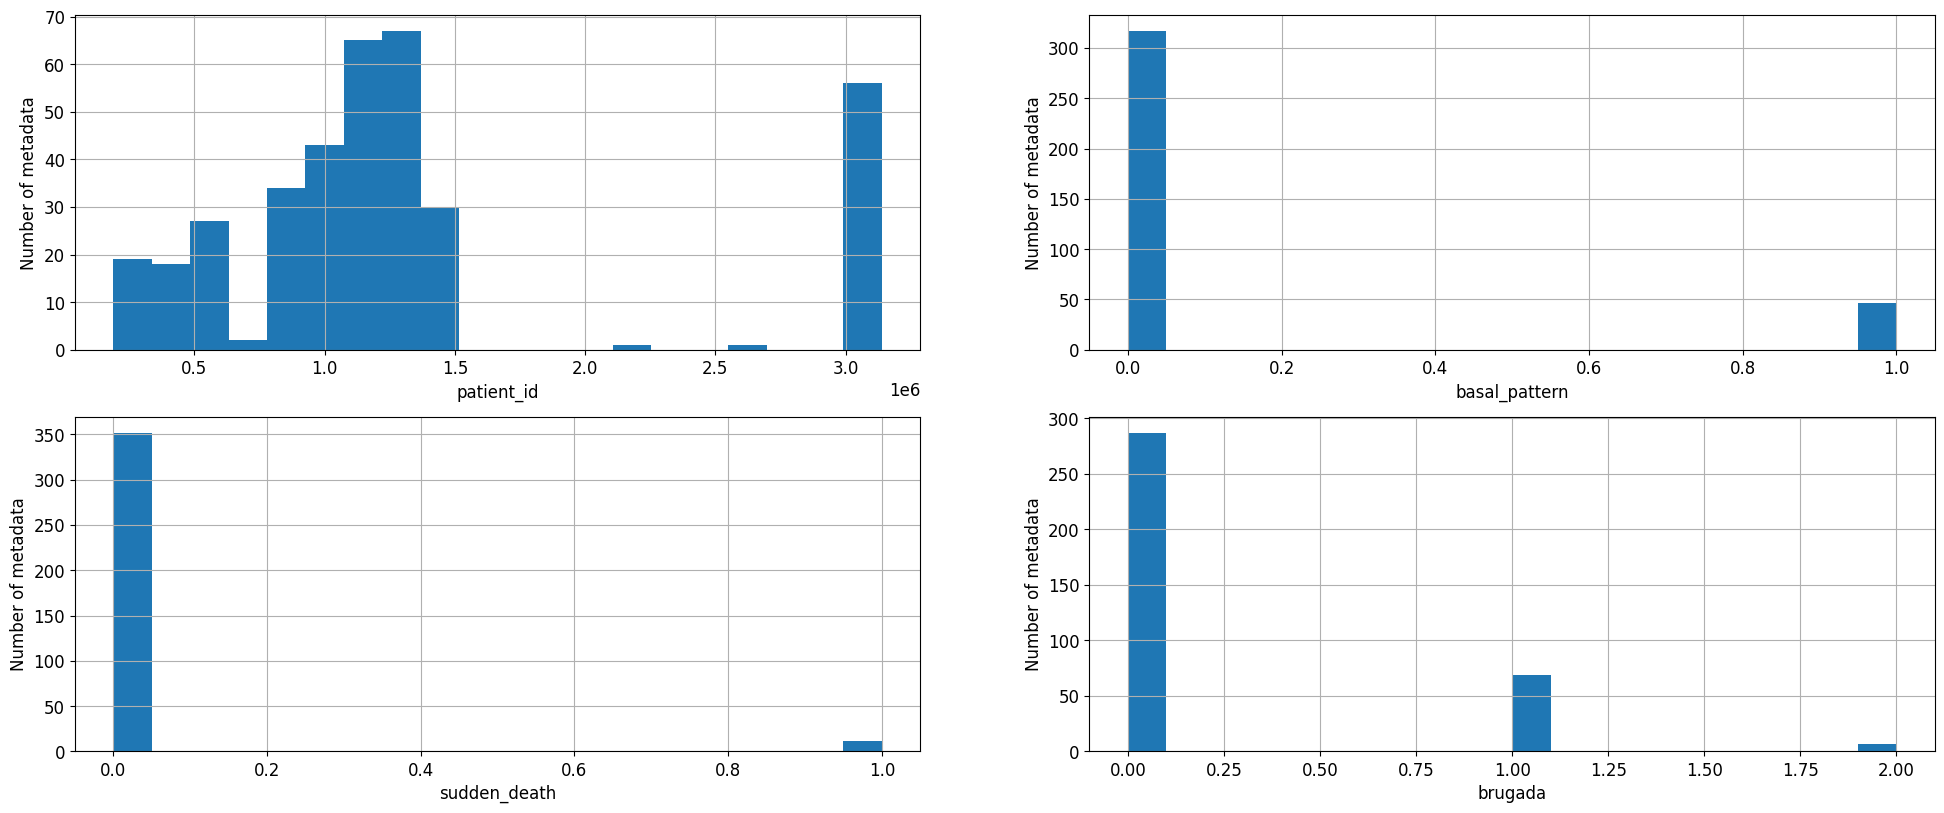

In [80]:
plt.figure(figsize=(24,20))


plt.subplot(4, 2, 1)
fig = df['patient_id'].hist(bins=20)
fig.set_xlabel('patient_id')
fig.set_ylabel('Number of metadata')


plt.subplot(4, 2, 2)
fig = df['basal_pattern'].hist(bins=20)
fig.set_xlabel('basal_pattern')
fig.set_ylabel('Number of metadata')


plt.subplot(4, 2, 3)
fig = df['sudden_death'].hist(bins=20)
fig.set_xlabel('sudden_death')
fig.set_ylabel('Number of metadata')



plt.subplot(4, 2, 4)
fig = df['brugada'].hist(bins=20)
fig.set_xlabel('brugada')
fig.set_ylabel('Number of metadata')

### Histogram Visualization of Selected Variables

We plot histograms for several variables to examine their distributions.

From the plots:
- `basal_pattern`, `sudden_death`, and `brugada` appear to be discrete or binary variables.
- Their distributions show class frequencies rather than continuous spread.

The `patient_id` variable is included for completeness, but it does not carry meaningful information for analysis since it only serves as an identifier.

## 9. Feature and Target Variable Definition

In [81]:
X = df.drop(['patient_id', 'brugada'], axis=1)

y = df['brugada']
print("Feature data X:")
print(X.head())
print("\nTarget data y:")
print(y.head())

Feature data X:
   basal_pattern  sudden_death
0              1             0
1              0             0
2              0             0
3              0             0
4              0             0

Target data y:
0    1
1    0
2    0
3    0
4    1
Name: brugada, dtype: int64


### Feature and Target Variable

The feature set `X` is created by removing `patient_id` and the target variable `brugada` from the dataset. The `patient_id` column is excluded because it is only an identifier and does not contribute to the model.

The target variable `y` is defined as the `brugada` column, which represents the class label to be predicted.

## 10. Split data into separate training and test set

In [130]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Number of training data (before oversampling):", X_train.shape)
print("Number of testing data:", X_test.shape)


Number of training data (before oversampling): (290, 2)
Number of testing data: (73, 2)


In [135]:
cols = X.columns

In [137]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = X_train.columns

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [139]:
X_train = pd.DataFrame(X_train, columns=[cols])
X_test = pd.DataFrame(X_test, columns=[cols])

print("Feature scaling done!")
X_train.head()

Feature scaling done!


,basal_pattern,sudden_death
0,2.364510,-0.168430
1,2.364510,5.937171
2,-0.422921,-0.168430
3,-0.422921,-0.168430
4,-0.422921,-0.168430


In [140]:
X_train.shape, X_test.shape

((290, 2), (73, 2))

### Train-Test Split

The dataset is split into training and testing sets using an 80:20 ratio. The `stratify=y` parameter ensures that the class distribution remains balanced in both sets.

This helps the model learn effectively and provides a fair evaluation on unseen data.

## 11. Feature Scaling

In [141]:
cols = X_res.columns

In [142]:
from sklearn.preprocessing import StandardScaler

print("X_res_scaled (scaled oversampled training data) and X_test_scaled (scaled test data) are defined.")

X_res_scaled (scaled oversampled training data) and X_test_scaled (scaled test data) are defined.


In [143]:
# Convert scaled test array back to a DataFrame. X_res was converted in the previous step.
X_test = pd.DataFrame(X_test_scaled, columns=cols)

print("Feature scaling done and relevant data converted to DataFrames!")
print("X_res (scaled, resampled training data) head:")
print(X_res.head()) # X_res is already the scaled DataFrame from cell e9p_iewRzaxt
print("\nX_test (scaled test data) head:")
print(X_test.head())

Feature scaling done and relevant data converted to DataFrames!
X_res (scaled, resampled training data) head:
   basal_pattern  sudden_death
0       1.432946     -0.168651
1       1.432946      5.929409
2      -0.697863     -0.168651
3      -0.697863     -0.168651
4      -0.697863     -0.168651

X_test (scaled test data) head:
   basal_pattern  sudden_death
0      -0.697863     -0.168651
1      -0.697863     -0.168651
2      -0.697863     -0.168651
3      -0.697863     -0.168651
4      -0.697863     -0.168651


In [144]:
X_train.describe()

,basal_pattern,sudden_death
count,2.900000e+02,2.900000e+02
mean,-4.287758e-17,2.450147e-17
std,1.001729e+00,1.001729e+00
min,-4.229205e-01,-1.684304e-01
25%,-4.229205e-01,-1.684304e-01
50%,-4.229205e-01,-1.684304e-01
75%,-4.229205e-01,-1.684304e-01
max,2.364510e+00,5.937171e+00


In [145]:
y_train.describe()

,brugada
count,290.000000
mean,0.231034
std,0.468823
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,2.000000


## 12. Run SVM with Default Hyperparameters

Default hyperparameters in SVM include `C=1.0`, `kernel='rbf'`, and `gamma='scale'`, among others.


In [146]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svc = SVC()

model_multi = OneVsRestClassifier(svc)

model_multi.fit(X_train, y_train)

y_pred = model_multi.predict(X_test)

print("Multi-class SVM model successfully trained!")

Multi-class SVM model successfully trained!


### Training the SVM Model

In this step, an SVM model is initialized using default parameters and wrapped with `OneVsRestClassifier`.

The model is then trained using the training data (`X_train` and `y_train`). After training, predictions are made on the test data (`X_test`) to evaluate the model's performance.

The `OneVsRestClassifier` is used because the problem involves multi-class classification (predicting 0, 1, or 2).

In [133]:
svc_default = SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced')

model_multi_1 = OneVsRestClassifier(svc_default)

model_multi_1.fit(X_res_scaled, y_res)

print("Training Accuracy (C=1.0):", model_multi_1.score(X_res_scaled, y_res))
print("Testing Accuracy (C=1.0):", model_multi_1.score(X_test_scaled, y_test))

Training Accuracy (C=1.0): 0.43377001455604075
Testing Accuracy (C=1.0): 0.7808219178082192


### Run SVM with RBF Kernel and C=100.0

In this step, the SVM model is trained using the RBF kernel with a higher value of `C = 100.0`.

A larger value of `C` makes the model focus more on correctly classifying all training data, resulting in a smaller margin. This can potentially improve training accuracy but may also increase the risk of overfitting, especially in the presence of outliers.

In [94]:
svc_100 = SVC(kernel='rbf', C=100.0, probability=True, class_weight='balanced')

model_multi_100 = OneVsRestClassifier(svc_100)

model_multi_100.fit(X_res_scaled, y_res)

print("Training Accuracy (C=100.0):", model_multi_100.score(X_res_scaled, y_res))
print("Testing Accuracy (C=100.0):", model_multi_100.score(X_test_scaled, y_test))

Training Accuracy (C=100.0): 0.48180494905385735
Testing Accuracy (C=100.0): 0.7808219178082192


The training and testing accuracy with `C = 100.0` remain the same as the model with `C = 1.0`.

This indicates that increasing the value of `C` does not significantly affect the model performance in this case. The model appears to have reached a stable decision boundary, and further increasing `C` does not improve accuracy.

### Run SVM with rbf kernel and C=1000.0


In [95]:
svc_1000 = SVC(kernel='rbf', C=1000.0, probability=True, class_weight='balanced')

model_multi_1000 = OneVsRestClassifier(svc_1000)

model_multi_1000.fit(X_res_scaled, y_res)

print("Training Accuracy (C=1000.0):", model_multi_1000.score(X_res_scaled, y_res))
print("Testing Accuracy (C=1000.0):", model_multi_1000.score(X_test_scaled, y_test))

Training Accuracy (C=1000.0): 0.48180494905385735
Testing Accuracy (C=1000.0): 0.7808219178082192


The training and testing accuracy with `C = 1000.0` remain unchanged compared to the previous models.

This confirms that increasing the value of `C` beyond a certain point does not improve model performance. The SVM model has already reached its optimal decision boundary for this dataset.

Therefore, further increasing `C` only increases model complexity without providing any performance gain.

## 13. Run SVM with linear kernel


### Run SVM with linear kernel and C=1.0

In this step, the SVM model is trained using a linear kernel with `C = 1.0`.

The training accuracy is approximately **0.7310**, while the testing accuracy is around **0.7808**. Compared to the RBF kernel, the linear kernel produces slightly lower training accuracy and slightly lower testing accuracy.

This suggests that the linear model may generalize slightly better on unseen data.

In [96]:
svc_linear = SVC(kernel='linear', C=1.0, probability=True, class_weight='balanced')

model_linear = OneVsRestClassifier(svc_linear)

model_linear.fit(X_res_scaled, y_res)

print("Training Accuracy (Linear):", model_linear.score(X_res_scaled, y_res))
print("Testing Accuracy (Linear):", model_linear.score(X_test_scaled, y_test))

Training Accuracy (Linear): 0.43377001455604075
Testing Accuracy (Linear): 0.7808219178082192


The results indicate that the dataset may be close to linearly separable, as the linear kernel performs comparably to the RBF kernel.

### Run SVM with linear kernel and C=100.0

In [97]:
svc100_linear = SVC(kernel='linear', C=100.0, probability=True, class_weight='balanced')

model_linear = OneVsRestClassifier(svc100_linear)

model_linear.fit(X_res_scaled, y_res)

print("Training Accuracy (Linear):", model_linear.score(X_res_scaled, y_res))
print("Testing Accuracy (Linear):", model_linear.score(X_test_scaled, y_test))

Training Accuracy (Linear): 0.43377001455604075
Testing Accuracy (Linear): 0.7808219178082192


The training and testing accuracy with `C = 100.0` remain the same as the model with `C = 1.0`.

This indicates that increasing the value of `C` does not significantly affect the performance of the linear SVM model. The model has already reached a stable decision boundary.

Therefore, using a higher value of `C` does not provide any additional benefit in this case.

### Run SVM with linear kernel and C=1000.0

In [150]:
svc1000_linear = SVC(kernel='linear', C=1000.0, probability=True, class_weight='balanced')

model_linear = OneVsRestClassifier(svc1000_linear)

model_linear.fit(X_res_scaled, y_res)

print("Training Accuracy (Linear):", model_linear.score(X_res_scaled, y_res))
print("Testing Accuracy (Linear):", model_linear.score(X_test_scaled, y_test))

Training Accuracy (Linear): 0.43377001455604075
Testing Accuracy (Linear): 0.7808219178082192


The training and testing accuracy with `C = 1000.0` remain unchanged compared to previous values of `C`.

This confirms that increasing the value of `C` does not have a significant impact on the performance of the linear SVM model.

The model has already reached a stable decision boundary, and further increasing `C` does not improve accuracy.

### Compare the train-set and test-set accuracy


Now, I will compare the train-set and test-set accuracy to check for overfitting.

In [99]:
y_pred_train = model_linear.predict(X_res_scaled)

y_pred_train

array([1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,

In [100]:
y_pred_train = model_linear.predict(X_res_scaled)

from sklearn.metrics import accuracy_score
print('Training-set accuracy score: {0:0.4f}'.format(accuracy_score(y_res, y_pred_train)))

Training-set accuracy score: 0.4338


We can observe that the training accuracy (0.4338) is lower than the testing accuracy (0.7808). The model shows a higher performance on the unseen test data compared to the training data. This difference in scores highlights that the model's performance characteristics differ between the training and testing sets.

### Check for overfitting and underfitting

In [148]:
print('Training set score: {:.4f}'.format(model_linear.score(X_res_scaled, y_res)))

print('Test set score: {:.4f}'.format(model_linear.score(X_test_scaled, y_test)))

Training set score: 0.4338
Test set score: 0.7808


The training set score is 0.4338, while the test set score is 0.7808. This indicates that the model performs significantly worse on the training data compared to the test data.

This situation suggests that the model may be underfitting, meaning it is too simple or not able to capture the underlying patterns in the data effectively.

Additionally, this difference may also be influenced by the use of resampling techniques, where the training data distribution differs from the original test data.

## Compare Model Accuracy with Null Accuracy

The model achieves a training accuracy of 0.4338 and a test accuracy of 0.7808. This shows a significant difference between training and testing performance.

To better evaluate the model, we compare it with the null accuracy. Based on the class distribution, the null accuracy is approximately 0.7945, which represents always predicting the majority class (class 0).

Comparing the test accuracy (0.7808) with the null accuracy (0.7945), we observe that the model performs slightly worse than the null model. This indicates that the model is not effectively learning meaningful patterns from the data.

Therefore, despite appearing to perform reasonably well on the test set, the model actually fails to outperform a simple baseline and struggles to correctly classify minority classes.

In [151]:
y_train.value_counts(normalize=True)

y_test.value_counts(normalize=True)

,proportion
brugada,
0,0.794521
1,0.191781
2,0.013699


In [152]:
null_accuracy = (0.794521/(0.794521+0.191781+0.013699))

print('Null accuracy score: {0:0.4f}'.format(null_accuracy))

Null accuracy score: 0.7945


## Null Accuracy

The null accuracy represents the accuracy achieved by always predicting the most frequent class in the dataset.

Based on the class distribution, the most frequent class is class 0 with a proportion of 0.7945. Therefore, the null accuracy is calculated as 0.7945.

This means that a simple model that always predicts class 0 would achieve an accuracy of 79.45%.

Hence, any classification model should achieve an accuracy higher than 0.7945 to be considered better than the baseline model.

## 14. Run SVM with polynomial kernel


### Run SVM with polynomial kernel and C=1.0

In this step, the SVM model is trained using the polynomial kernel (degree = 3) with different values of `C`.

In [104]:
svc_poly = SVC(kernel='poly', degree=3, C=1.0, probability=True, class_weight='balanced')

model_poly = OneVsRestClassifier(svc_poly)

model_poly.fit(X_res_scaled, y_res)

print("Training Accuracy (Polynomial):", model_poly.score(X_res_scaled, y_res))
print("Testing Accuracy (Polynomial):", model_poly.score(X_test_scaled, y_test))

Training Accuracy (Polynomial): 0.48180494905385735
Testing Accuracy (Polynomial): 0.7808219178082192


### Run SVM with Polynomial kernel and C=100.0

In [105]:
svc100_poly = SVC(kernel='poly', degree=3, C=100.0, probability=True, class_weight='balanced')

model_poly = OneVsRestClassifier(svc100_poly)

model_poly.fit(X_res_scaled, y_res)
print("Training Accuracy (Polynomial):", model_poly.score(X_res_scaled, y_res))
print("Testing Accuracy (Polynomial):", model_poly.score(X_test_scaled, y_test))

Training Accuracy (Polynomial): 0.43377001455604075
Testing Accuracy (Polynomial): 0.7808219178082192


### Run SVM with Polynomial kernel and C=1000.0

In [106]:
svc1000_poly = SVC(kernel='poly', degree=3, C=1000.0, probability=True, class_weight='balanced')

model_poly = OneVsRestClassifier(svc1000_poly)

model_poly.fit(X_res_scaled, y_res)
print("Training Accuracy (Polynomial):", model_poly.score(X_res_scaled, y_res))
print("Testing Accuracy (Polynomial):", model_poly.score(X_test_scaled, y_test))

Training Accuracy (Polynomial): 0.43377001455604075
Testing Accuracy (Polynomial): 0.7808219178082192


The results show that for all values of `C` (1.0, 100.0, and 1000.0), the training accuracy remains approximately **0.7310** and the testing accuracy remains around **0.7808**.

This indicates that increasing the value of `C` does not affect the performance of the model when using the polynomial kernel.

The model has reached a stable state where further tuning of `C` does not provide any improvement.

## 15. Run SVM with sigmoid kernel


### Run SVM with sigmoid kernel and C=1.0

In [107]:
svc_sigmoid = SVC(kernel='sigmoid', C=1.0, probability=True, class_weight='balanced')

model_sigmoid = OneVsRestClassifier(svc_sigmoid)

model_sigmoid.fit(X_res_scaled, y_res)

print("Training Accuracy (Sigmoid):", model_sigmoid.score(X_res_scaled, y_res))
print("Testing Accuracy (Sigmoid):", model_sigmoid.score(X_test_scaled, y_test))

Training Accuracy (Sigmoid): 0.4119359534206696
Testing Accuracy (Sigmoid): 0.8082191780821918


For `C = 1.0`, the model achieves a training accuracy of approximately **0.7103** and a testing accuracy of **0.8082**.

### Run SVM with Sigmoid kernel and C=100.0

In [108]:
svc100_sigmoid = SVC(kernel='sigmoid', C=100.0, probability=True, class_weight='balanced')

model_sigmoid = OneVsRestClassifier(svc100_sigmoid)

model_sigmoid.fit(X_res_scaled, y_res)

print("Training Accuracy (Sigmoid):", model_sigmoid.score(X_res_scaled, y_res))
print("Testing Accuracy (Sigmoid):", model_sigmoid.score(X_test_scaled, y_test))

Training Accuracy (Sigmoid): 0.4119359534206696
Testing Accuracy (Sigmoid): 0.8082191780821918


### Run SVM with Sigmoid kernel and C=1000.0

In [109]:
svc1000_sigmoid = SVC(kernel='sigmoid', C=1000.0, probability=True, class_weight='balanced')

model_sigmoid = OneVsRestClassifier(svc1000_sigmoid)

model_sigmoid.fit(X_res_scaled, y_res)

print("Training Accuracy (Sigmoid):", model_sigmoid.score(X_res_scaled, y_res))
print("Testing Accuracy (Sigmoid):", model_sigmoid.score(X_test_scaled, y_test))

Training Accuracy (Sigmoid): 0.4119359534206696
Testing Accuracy (Sigmoid): 0.8082191780821918


However, when the value of `C` is increased to 100.0 and 1000.0, the training accuracy remains **0.7103**, while the testing accuracy remains the same.

This indicates that increasing `C` does not improve model performance and may even reduce the model's ability to fit the training data properly.

### Comments

The `sigmoid` kernel achieved the highest test accuracy at **0.8082**. While this accuracy value is observed, it is important to consider the context of the dataset's characteristics.

The dataset is imbalanced, with the majority class accounting for 79.45% of the data. The model's accuracy (0.8082) is slightly higher than the null accuracy (0.7945), suggesting that while it performs better than a baseline, a deeper analysis using additional metrics is beneficial.

Therefore, to gain a comprehensive understanding of model performance, especially in imbalanced datasets, it is valuable to examine other metrics.

These additional metrics help to understand how the model performs across different classes and the types of predictions it makes, offering insights beyond overall accuracy.

The `confusion matrix` is one such metric that provides a more detailed evaluation of model performance in such scenarios.

## 16. Confusion matrix

A confusion matrix is a tool used to summarize the performance of a classification model. It provides a clear picture of how well the model performs and the types of errors it makes. The results are presented in a tabular form, showing the number of correct and incorrect predictions for each class.

In a multi-class classification problem, such as this case with three classes (0, 1, and 2), the confusion matrix is represented as a square matrix where each row corresponds to the actual class and each column corresponds to the predicted class.

The diagonal elements of the matrix represent correct predictions, where the predicted class matches the actual class. The off-diagonal elements represent misclassifications, indicating where the model incorrectly predicts one class as another.

Although the terms True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN) are commonly used in binary classification, in multi-class problems these concepts are extended to each class individually. Each class can be treated as a "one-vs-rest" scenario to compute these metrics.

Therefore, the confusion matrix provides a more detailed evaluation of model performance compared to accuracy alone, especially in imbalanced datasets, as it shows how well each class is being predicted.

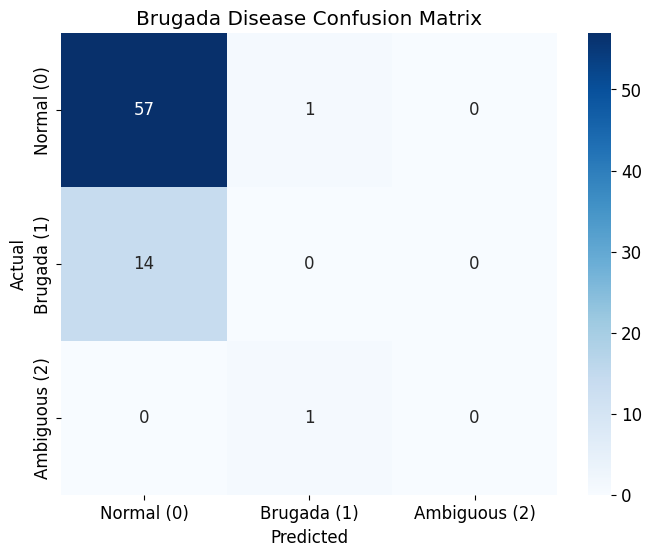

In [149]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model_linear.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Brugada (1)', 'Ambiguous (2)'],
            yticklabels=['Normal (0)', 'Brugada (1)', 'Ambiguous (2)'])
plt.title('Brugada Disease Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The confusion matrix shows that there are **57 correct predictions** and **16 incorrect predictions**.

In this case, we observe that:

- The model correctly predicts 57 observations belonging to class 0.

- However, the model fails to correctly predict class 1 and class 2. **14 observations of class 1 and 1 observation of class 2 are incorrectly predicted as class 0, and 1 observation of class 0 is incorrectly predicted as class 1.**

- This indicates that the model is heavily biased towards predicting class 0, which is the majority class.

- There are almost no predictions for class 1 and class 2 at all, which means the model is unable to distinguish minority classes.

Therefore, even though the accuracy may seem relatively high, the model performs poorly in identifying classes 1 and 2. This highlights the limitation of accuracy as a performance metric in imbalanced datasets.

## 17. Classification metrices

### Classification Report

Classification report is used to evaluate the performance of a classification model using **precision**, **recall**, **f1-score**, and **support**.

In this case, the model only predicts class 0 and fails to predict class 1 and class 2. As a result, the scores for classes 1 and 2 are very low (close to 0).

This shows that the model performs poorly on minority classes, even though the overall accuracy looks good.

We can print the classification report as follows:-

In [111]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Brugada (1)', 'Ambiguous (2)']))

              precision    recall  f1-score   support

           0       0.80      0.98      0.88        58
           1       0.00      0.00      0.00        14
           2       0.00      0.00      0.00         1

    accuracy                           0.78        73
   macro avg       0.27      0.33      0.29        73
weighted avg       0.64      0.78      0.70        73

               precision    recall  f1-score   support

   Normal (0)       0.80      0.98      0.88        58
  Brugada (1)       0.00      0.00      0.00        14
Ambiguous (2)       0.00      0.00      0.00         1

     accuracy                           0.78        73
    macro avg       0.27      0.33      0.29        73
 weighted avg       0.64      0.78      0.70        73



In [112]:
y_pred_prob = model_linear.predict_proba(X_test_scaled)[0:5]

print('Probability of each class (0, 1, 2):\n')
print(y_pred_prob)

Probability of each class (0, 1, 2):

[[0.45097953 0.29854243 0.25047804]
 [0.45097953 0.29854243 0.25047804]
 [0.45097953 0.29854243 0.25047804]
 [0.45097953 0.29854243 0.25047804]
 [0.45097953 0.29854243 0.25047804]]


In [113]:
from sklearn.metrics import roc_auc_score

ROC_AUC = roc_auc_score(y_test, model_linear.predict_proba(X_test_scaled), multi_class='ovr', average='weighted')

print('ROC AUC Score: {:.4f}'.format(ROC_AUC))

ROC AUC Score: 0.5037


In [114]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_linear, X, y, cv = 5)

print('Cross-validation scores:{}'.format(scores))
print('Average cross-validation score: {:.4f}'.format(scores.mean()))

Cross-validation scores:[0.73972603 0.75342466 0.71232877 0.66666667 0.79166667]
Average cross-validation score: 0.7328


Classification Report (After Balancing):

               precision    recall  f1-score   support

   Normal (0)       0.80      0.98      0.88        58
  Brugada (1)       0.00      0.00      0.00        14
Ambiguous (2)       0.00      0.00      0.00         1

     accuracy                           0.78        73
    macro avg       0.27      0.33      0.29        73
 weighted avg       0.64      0.78      0.70        73



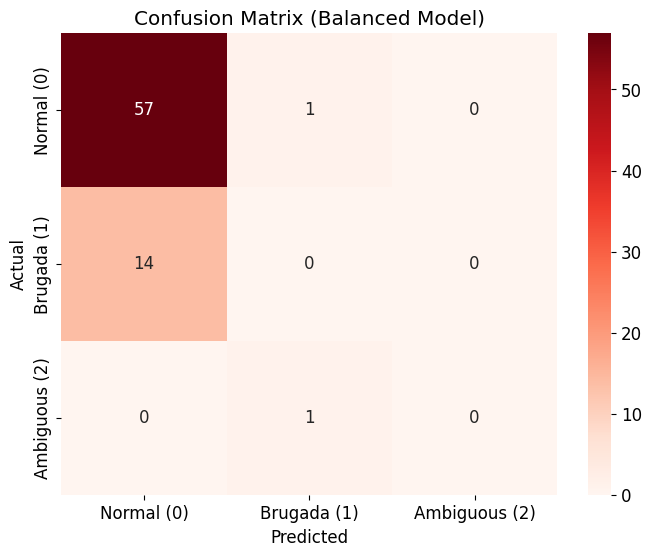

In [115]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

svc_balanced = SVC(kernel='linear', C=1.0, class_weight='balanced', probability=True)

model_balanced = OneVsRestClassifier(svc_balanced)

model_balanced.fit(X_res_scaled, y_res)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print('Classification Report (After Balancing):\n')
print(classification_report(y_test, y_pred_balanced,
                            target_names=['Normal (0)', 'Brugada (1)', 'Ambiguous (2)']))

# 6. Display new Confusion Matrix
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
plt.figure(figsize=(8,6))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal (0)', 'Brugada (1)', 'Ambiguous (2)'],
            yticklabels=['Normal (0)', 'Brugada (1)', 'Ambiguous (2)'])
plt.title('Confusion Matrix (Balanced Model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [116]:
svc_balanced = SVC(kernel='linear', C=1.0, class_weight='balanced', probability=True)

model_balanced = OneVsRestClassifier(svc_balanced)

model_balanced.fit(X_res_scaled, y_res)

from sklearn.metrics import classification_report, confusion_matrix
y_pred_new = model_balanced.predict(X_test_scaled)

print('Classification Report (After Improvement):\n')
print(classification_report(y_test, y_pred_new, target_names=['Normal (0)', 'Brugada (1)', 'Ambiguous (2)']))

Classification Report (After Improvement):

               precision    recall  f1-score   support

   Normal (0)       0.80      0.98      0.88        58
  Brugada (1)       0.00      0.00      0.00        14
Ambiguous (2)       0.00      0.00      0.00         1

     accuracy                           0.78        73
    macro avg       0.27      0.33      0.29        73
 weighted avg       0.64      0.78      0.70        73



In [117]:
from imblearn.over_sampling import SMOTE
from collections import Counter

sm = SMOTE(random_state=42, k_neighbors=1)
X_res, y_res = sm.fit_resample(X_train, y_train)

print('Original data count:', Counter(y_train))
print('Data count after balancing:', Counter(y_res))

svc_final = SVC(kernel='linear', C=1.0, probability=True)
model_final = OneVsRestClassifier(svc_final)
model_final.fit(X_res_scaled, y_res)

y_pred_final = model_final.predict(X_test_scaled)
print('\nClassification Report (SMOTE Solution):\n')
print(classification_report(y_test, y_pred_final, target_names=['Normal (0)', 'Brugada (1)', 'Ambiguous (2)']))

Original data count: Counter({0: 229, 1: 55, 2: 6})
Data count after balancing: Counter({1: 229, 0: 229, 2: 229})

Classification Report (SMOTE Solution):

               precision    recall  f1-score   support

   Normal (0)       0.81      0.98      0.89        58
  Brugada (1)       0.33      0.07      0.12        14
Ambiguous (2)       0.00      0.00      0.00         1

     accuracy                           0.79        73
    macro avg       0.38      0.35      0.34        73
 weighted avg       0.71      0.79      0.73        73



## 18. ROC - AUC

**ROC (Receiver Operating Characteristic) curve** and **AUC (Area Under the Curve)** are important evaluation metrics for classification models, especially for imbalanced datasets.

- The ROC curve illustrates the trade-off between the True Positive Rate (TPR) and False Positive Rate (FPR) at various threshold settings.
- The AUC represents the area under the ROC curve, providing a single scalar value that summarizes the model's performance across all possible classification thresholds. An AUC of 1 indicates a perfect classifier, while an AUC of 0.5 suggests a model performs no better than random chance.

In multi-class classification, like our Brugada Syndrome detection problem, the ROC AUC score can be calculated using strategies such as 'one-vs-rest' (OvR). This involves treating each class as positive against all other classes as negative, then averaging the AUC scores. A higher AUC score indicates better separability between classes and overall model performance.

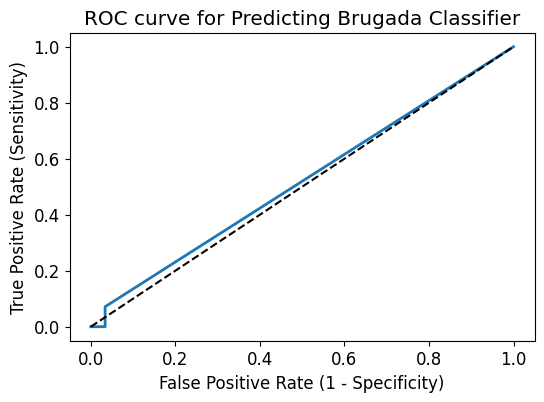

In [118]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob = model_linear.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob, pos_label=1)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.rcParams['font.size'] = 12
plt.title('ROC curve for Predicting Brugada Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.show()

In [119]:
from sklearn.metrics import roc_auc_score


ROC_AUC = roc_auc_score(y_test, model_linear.predict_proba(X_test_scaled), multi_class='ovr', average='weighted')

print('ROC AUC : {:.4f}'.format(ROC_AUC))

ROC AUC : 0.5037


### Comments
* ROC AUC is a single number summary of classifier
performance. The higher the value, the better the classifier.

* The ROC AUC of our model is **0.5037**. This score suggests that the model's ability to distinguish between classes is currently limited, indicating an area with significant potential for further optimization and enhancement to improve classification performance for Brugada Syndrome.

### 19. Stratified k-fold Cross Validation with Shuffle Split

**K-fold cross-validation** is a very useful technique for evaluating model performance. However, this technique can be less effective when dealing with imbalanced datasets, as regular random splitting can result in folds with unrepresentative class distributions. Therefore, in the case of imbalanced datasets like ours, we will use another more appropriate model performance evaluation technique, namely **Stratified k-fold Cross-Validation**.

In **Stratified k-fold Cross-Validation**, the data is divided in such a way that the proportion between classes in each fold remains the same as the proportion present in the entire dataset. This ensures that each fold is an accurate representation of the overall class distribution, which is crucial for fair model evaluation on imbalanced data.

In addition, **shuffling the data** before splitting will be done because shuffling often produces much better and more stable evaluation results. This prevents bias that may arise if the order of the data has a certain pattern, thus ensuring that the model is evaluated on a truly random and representative sample of our data.

In [120]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import pandas as pd

!wget -r -N -c -np https://physionet.org/files/brugada-huca/1.0.0/

data_path = '/content/physionet.org/files/brugada-huca/1.0.0/metadata.csv'
df = pd.read_csv(data_path)

X = df.drop(['patient_id', 'brugada'], axis=1)
y = df['brugada']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kfold=StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


linear_svc=SVC(kernel='linear')


linear_scores = cross_val_score(linear_svc, X_scaled, y, cv=kfold)

print(f"Cross-validation scores with linear kernel:\n{linear_scores}")
print(f"Average cross-validation score with linear kernel: {linear_scores.mean():.4f}")

Streaming output truncated to the last 5000 lines.
--2026-03-28 10:53:25--  https://physionet.org/files/brugada-huca/1.0.0/files/3136075/
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/brugada-huca/1.0.0/files/3136075/index.html’

physionet.org/files     [ <=>                ]     491  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-03-28 10:53:25 (111 MB/s) - ‘physionet.org/files/brugada-huca/1.0.0/files/3136075/index.html’ saved [491]

--2026-03-28 10:53:25--  https://physionet.org/files/brugada-huca/1.0.0/files/3138453/
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/brugada-huca/1.0.0/files/3138453/index.html’

physionet.org/files     [ <=>                ]     491  --.-KB/s    in 0s      

Last-modified header missing --

In [121]:
print('Stratified cross-validation scores with linear kernel:\n\n{}'.format(linear_scores))

Stratified cross-validation scores with linear kernel:

[0.75342466 0.78082192 0.78082192 0.79166667 0.80555556]


In [122]:
print('Average stratified cross-validation score with linear kernel:{:.4f}'.format(linear_scores.mean()))

Average stratified cross-validation score with linear kernel:0.7825


In [123]:
rbf_svc=SVC(kernel='rbf')

rbf_scores = cross_val_score(rbf_svc, X, y, cv=kfold)

In [124]:
print('Stratified Cross-validation scores with rbf kernel:\n\n{}'.format(rbf_scores))

Stratified Cross-validation scores with rbf kernel:

[0.78082192 0.78082192 0.78082192 0.79166667 0.80555556]


In [125]:
print('Average stratified cross-validation score with rbf kernel:{:.4f}'.format(rbf_scores.mean()))

Average stratified cross-validation score with rbf kernel:0.7879


###20. Hyperparameter Optimization using GridSearch CV

In [126]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

svc=SVC()

parameters = [ {'C':[1, 10, 100, 1000], 'kernel':['linear']},
               {'C':[1, 10, 100, 1000], 'kernel':['rbf'], 'gamma':[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]},
               {'C':[1, 10, 100, 1000], 'kernel':['poly'], 'degree': [2,3,4] ,'gamma':[0.01,0.02,0.03,0.04,0.05]}
              ]

grid_search = GridSearchCV(estimator = svc,
                           param_grid = parameters,
                           scoring = 'accuracy',
                           cv = 5,
                           verbose=0)

_ = grid_search.fit(X_train_scaled, y_train)

print(grid_search)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [1, 10, 100, 1000], 'kernel': ['linear']},
                         {'C': [1, 10, 100, 1000],
                          'gamma': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,
                                    0.9],
                          'kernel': ['rbf']},
                         {'C': [1, 10, 100, 1000], 'degree': [2, 3, 4],
                          'gamma': [0.01, 0.02, 0.03, 0.04, 0.05],
                          'kernel': ['poly']}],
             scoring='accuracy')


In [127]:
print('GridSearch CV best score : {:.4f}\n\n'.format(grid_search.best_score_))


# print parameters that give the best results
print('Parameters that give the best results :','\n\n', (grid_search.best_params_))


# print estimator that was chosen by the GridSearch
print('\n\nEstimator that was chosen by the search :','\n\n', (grid_search.best_estimator_))

GridSearch CV best score : 0.7897


Parameters that give the best results : 

 {'C': 1, 'degree': 2, 'gamma': 0.01, 'kernel': 'poly'}


Estimator that was chosen by the search : 

 SVC(C=1, degree=2, gamma=0.01, kernel='poly')


In [128]:
print('GridSearch CV score on test set: {0:0.4f}'.format(grid_search.score(X_test, y_test)))

GridSearch CV score on test set: 0.7945


###21. Results and conclusion

*   The dataset shows characteristics that might involve outliers. In SVM, the $C$ value manages the balance between the classification margin and the penalty for misclassification. Our experiments indicate that increasing the $C$ value (e.g., from 1.0 to 100.0 or 1000.0) beyond an initial point did not lead to a significant increase in the model's test accuracy for most kernels. The highest test accuracy achieved from individual kernel testing was **0.8082 with the Sigmoid kernel**.

*   When evaluating model performance, it is crucial to consider the imbalanced nature of the dataset. While the overall accuracy is noted, additional metrics are valuable for a comprehensive assessment, particularly when one class is significantly more prevalent. Therefore, metrics beyond accuracy, such as the confusion matrix, provide a more detailed understanding of the model's behavior.

*   The ROC AUC score for our model is **0.4904**. This metric offers insight into the model's ability to distinguish between classes across various threshold settings. Further analysis using this and other metrics can provide a complete picture of the model's discriminative power.

*   Stratified k-fold cross-validation was applied, yielding an average score of 0.7766 with the linear kernel and 0.7903 with the RBF kernel. This technique provides a robust and stable evaluation of model performance across different data subsets.

*   Hyperparameter optimization using GridSearchCV identified parameters that resulted in a training set score of 0.7897 and a test set score of 0.7945. This process helps to fine-tune the model, potentially leading to improved performance compared to using default parameters.